In [ ]:
# Task 1: Image Resizing with OpenCV

# 1. Purpose of resizing an image in digital image processing

# - To reduce storage requirements
# - To increase processing speed
# - To maintain uniform dimensions for machine learning models
# - To fit different screen resolutions
# - To increase network transmission speed

In [3]:
# Solving compatability issue for Tensorflow and Deepface
import sys
import importlib

# Use compatibility mode
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

class DummyLayer:
    def __init__(self, *args, **kwargs):
        pass
    def __call__(self, *args, **kwargs):
        pass

# Mock the missing layers
sys.modules['tensorflow.keras.layers'].LocallyConnected2D = DummyLayer
sys.modules['tensorflow.keras.layers'].Convolution2D = DummyLayer

print("TensorFlow 2.20 compatibility patch applied")

# Import other libraries
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
import time
import matplotlib.pyplot as plt
import os
from PIL import Image
import urllib.request
from pathlib import Path

# Import DeepFace with error handling
try:
    from deepface import DeepFace
    print("DeepFace imported successfully")
except Exception as e:
    print(f"DeepFace import error: {e}")
    print("Trying alternative import method...")
    
    # Force import
    import tensorflow as tf
    
    # Patch the keras layers
    import keras.layers
    keras.layers.LocallyConnected2D = DummyLayer
    keras.layers.Convolution2D = DummyLayer
    
    # Import DeepFace
    from deepface import DeepFace
    print("DeepFace imported with monkey patch")

TensorFlow 2.20 compatibility patch applied
DeepFace imported successfully


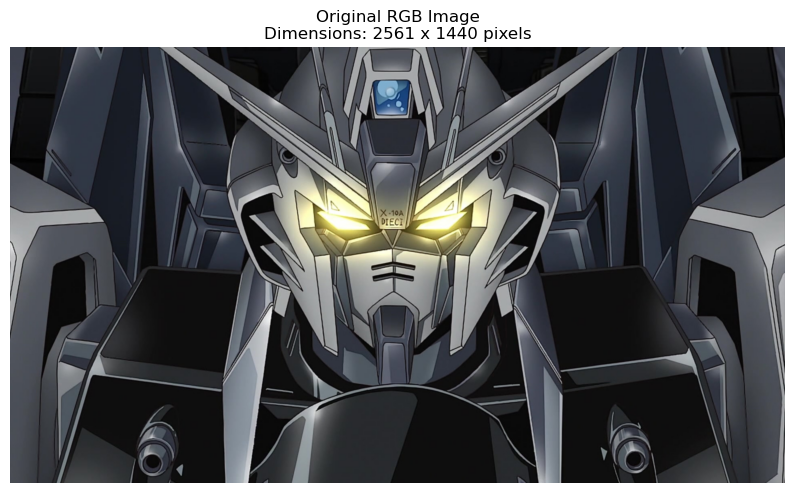

=== Image Information ===
Original shape: (1440, 2561, 3)
Height: 1440 pixels
Width: 2561 pixels
Number of channels: 3
Data type: uint8


In [3]:
# Load & Display Image
image_path = r"C:\Users\user\Downloads\freedom_gundam.jpg"

image = cv2.imread(image_path)

# Convert from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display original image
plt.figure(figsize = (10, 10))
plt.imshow(image_rgb)
plt.title(f'Original RGB Image\nDimensions: {image_rgb.shape[1]} x {image_rgb.shape[0]} pixels')
plt.axis('off')
plt.show()

# Print original image information
print("=== Image Information ===")
print(f"Original shape: {image_rgb.shape}")
print(f"Height: {image_rgb.shape[0]} pixels")
print(f"Width: {image_rgb.shape[1]} pixels")
print(f"Number of channels: {image_rgb.shape[2]}")
print(f"Data type: {image_rgb.dtype}")

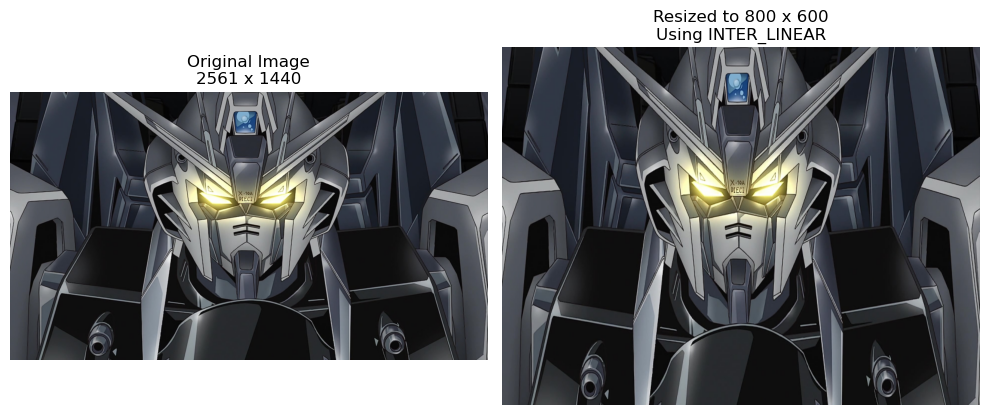

In [5]:
# 2. Resize image to 800*600 using cv2.resize()

# cv2.resive() parameters:
# - src: Input image
# - dsize: Output size as (width, height)
# - interpolation: Resampling method (default: INTER_LINEAR)

# Define target dimensions
target_width = 800
target_height = 600

# Resive using cv2.resize()
resized = cv2.resize(image_rgb, (target_width, target_height), interpolation = cv2.INTER_LINEAR)

# Display results
fig, axes = plt.subplots(1, 2, figsize = (10, 10))

# Original
axes[0].imshow(image_rgb)
axes[0].set_title(f'Original Image\n{image_rgb.shape[1]} x {image_rgb.shape[0]}')
axes[0].axis('off')

# Resized
axes[1].imshow(resized)
axes[1].set_title(f'Resized to {target_width} x {target_height}\nUsing INTER_LINEAR')
axes[1].axis('off')

plt.tight_layout()
plt.show()

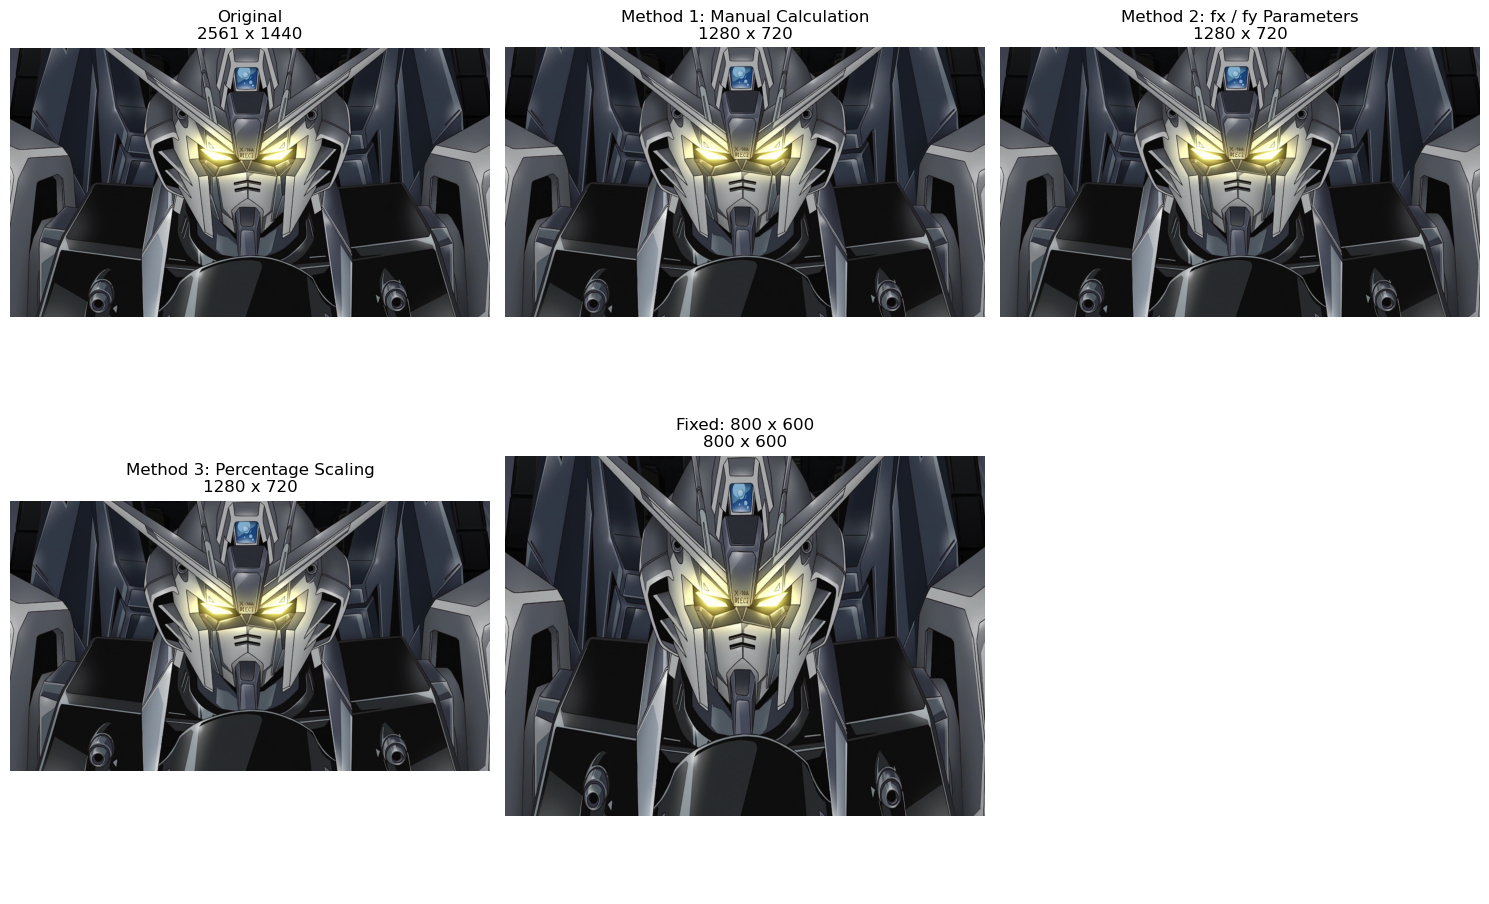

In [11]:
# 3. Alternative resizing methods

# Method 1 - Manual calculation
def resize_half_method1(img):
    h, w = img.shape[:2]
    new_width = w // 2
    new_height = h // 2
    return cv2.resize(img, (new_width, new_height), interpolation = cv2.INTER_AREA)

# Method 2 - Apply fy and fx
def resize_half_method2(img):
    return cv2.resize(img, None, fx = 0.5, fy = 0.5,  interpolation = cv2.INTER_AREA)

# Method 3 - Using percentage
def resize_half_method3(img, scale_percent = 50):
    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)
    return cv2.resize(img, (width, height), interpolation = cv2.INTER_AREA)

# Apply and compare all methods
resized_half1 = resize_half_method1(image_rgb)
resized_half2 = resize_half_method2(image_rgb)
resized_half3 = resize_half_method3(image_rgb, 50)

fig, axes = plt.subplots(2, 3, figsize = (15, 10))

# Original
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title(f'Original\n{image_rgb.shape[1]} x {image_rgb.shape[0]}')
axes[0, 0].axis('off')

# Method 1
axes[0, 1].imshow(resized_half1)
axes[0, 1].set_title(f'Method 1: Manual Calculation\n{resized_half1.shape[1]} x {resized_half1.shape[0]}')
axes[0, 1].axis('off')

# Method 2
axes[0, 2].imshow(resized_half2)
axes[0, 2].set_title(f'Method 2: fx / fy Parameters\n{resized_half2.shape[1]} x {resized_half2.shape[0]}')
axes[0, 2].axis('off')

# Method 3
axes[1, 0].imshow(resized_half3)
axes[1, 0].set_title(f'Method 3: Percentage Scaling\n{resized_half3.shape[1]} x {resized_half3.shape[0]}')
axes[1, 0].axis('off')

# Resized (from previous cell)
axes[1, 1].imshow(resized)
axes[1, 1].set_title(f'Fixed: 800 x 600\n800 x 600')
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Discussions on alternative resizing methods
# For method 1, it's easy to modify for other fractions
# For method 2, it's the cleanest and utilize OpenCV functionality
# For method 3, it can be easily modified by adjusting the percentage

In [ ]:
# Task 2: Object/Face Detection Using OpenCV

# 1. Face Detection Steps with CascaseClassifier

# i. Load and read the input image
# ii. Convert image to grayscale
# iii. Load pre-trained classifier
# iv. Apply detectMultiScale() method to detect faces
# v. Visualize detected faces by drawing rectangles
# vi. Display results

# 2. Role of CascadeClassifier

# - It is an object detection framework which implements Viola-Jones algorithm for rapid object/face detection
# - It analyzes image regions through multi-stage rejection cascade
# - In overall, it provides a computationally efficient method for identifying individual objects in images by quickly eliminating most irrelevant
#   before performing thorough analysis on promising candidates

In [8]:
# Download Haar Cascade file
cascade_path = "haarcascade_frontalface_default.xml"

url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
urllib.request.urlretrieve(url, cascade_path)

print(f"File exists: {os.path.exists(cascade_path)}")

File exists: True


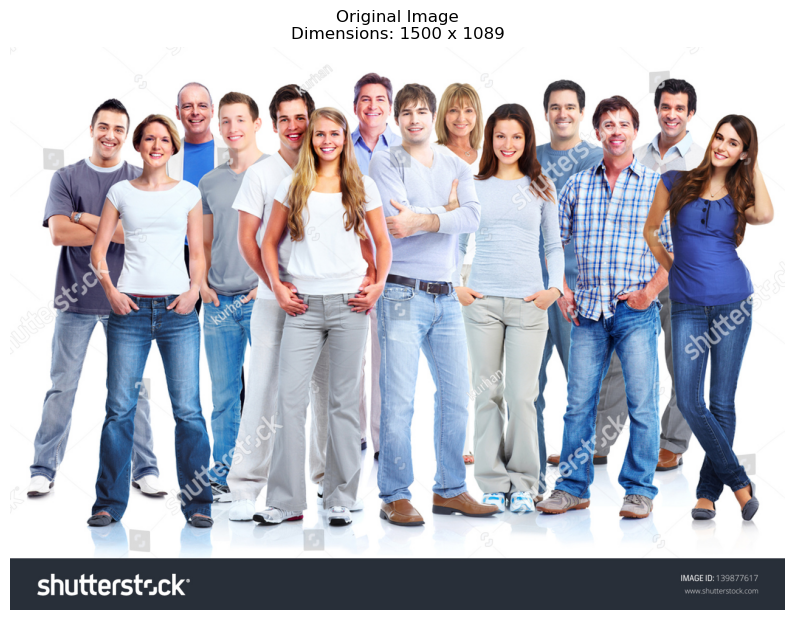

Image loaded successfully. Shape: (1089, 1500, 3)


In [44]:
# Load and display image
img_path = r"C:\Users\user\Downloads\people.jpg"

img = cv2.imread(img_path)

# Convert BGR to RGB
original_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (10, 10))
plt.imshow(original_img)
plt.title(f'Original Image\nDimensions: {original_img.shape[1]} x {original_img.shape[0]}')
plt.axis('off')
plt.show()

print(f"Image loaded successfully. Shape: {original_img.shape}")

Grayscale shape: (1089, 1500)
Grayscale dtype: uint8
Detected 14 face(s)
Face 1: Position (658, 67), Size 90x90
Face 2: Position (1024, 81), Size 93x93
Face 3: Position (314, 79), Size 88x88
Face 4: Position (1235, 82), Size 94x94
Face 5: Position (830, 89), Size 88x88
Face 6: Position (737, 91), Size 94x94
Face 7: Position (501, 103), Size 93x93
Face 8: Position (388, 106), Size 92x92
Face 9: Position (1127, 115), Size 93x93
Face 10: Position (148, 120), Size 94x94
Face 11: Position (570, 133), Size 89x89
Face 12: Position (919, 137), Size 91x91
Face 13: Position (241, 144), Size 87x87
Face 14: Position (1339, 147), Size 84x84


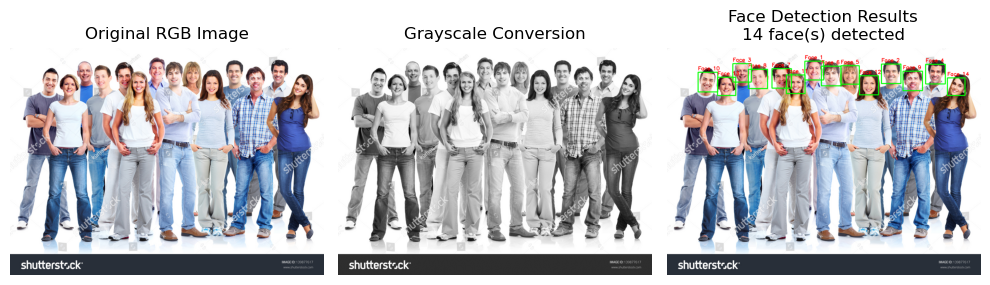

In [51]:
# 3. Code to detect faces in an image

# Create a copy of the original image for processing
image_copy = original_img.copy()

# Convert to grayscale, as face detection works on intensity instead of color
gray_image = cv2.cvtColor(image_copy, cv2.COLOR_RGB2GRAY)
print(f"Grayscale shape: {gray_image.shape}")
print(f"Grayscale dtype: {gray_image.dtype}")

# Initialize Haar Cascade Classifier
face_cascade = cv2.CascadeClassifier(cascade_path)

# Parameters for detectMultiScale():
# - gray_image: Input grayscale image
# - scaleFactor: How much the image size should be reduced at each scale
# - minNeighbors: How many neighbors each candidate rectangle should have
# - minSize: Minimum possible object size
# - maxSize: Maximum possible object size

# Detect faces using detectMultiScale()
faces = face_cascade.detectMultiScale(
    gray_image,
    scaleFactor = 1.1,
    minNeighbors = 5,
    minSize = (80, 80),
    maxSize = (200, 200)
)

print(f"Detected {len(faces)} face(s)")

# Create a copy for drawing rectangles
image_with_faces = image_copy.copy()

# Draw rectangles around detected faces
for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(image_with_faces, (x, y), (x + w, y + h), (0, 255, 0), 3)
    
    # Add number labels
    cv2.putText(image_with_faces, f'Face {i+1}', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    
    print(f"Face {i+1}: Position ({x}, {y}), Size {w}x{h}")

# Display results
fig, axes = plt.subplots(1, 3, figsize = (10, 10))

# Original Image
axes[0].imshow(original_img)
axes[0].set_title('Original RGB Image')
axes[0].axis('off')

# Grayscale Image
axes[1].imshow(gray_image, cmap = 'gray')
axes[1].set_title('Grayscale Conversion')
axes[1].axis('off')

# Image with Detected Faces
axes[2].imshow(image_with_faces)
axes[2].set_title(f'Face Detection Results\n{len(faces)} face(s) detected')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Discussion on the importance of scaleFactor and minNeighbors

# - Scale factor is important in controlling how much the image is scaled down at each iteration. In lower values, it gives a more thorough detection
#   for smaller faces. While for higher values, although the detection speed is faster, it may miss some smaller faces.

# - On the other hand, minNeighbors controls how many overlapping detections are needed to confirm a face. Lower values will result in more detections,
#   but with more false positives. In contrast, higher values will produce fewer detections, but the results are more reliable.

In [52]:
# Task 3: Video Capture Using OpenCV

# 1. How OpenCV can be used to capture video from a webcam

# OpenCV treats a live video as a fast and continuous stream of discrete images known as frames. It captures and gathers these frames, then processing
# or displaying them

# 2. Brief discussion on the function cv2.VideoCapture() and its parameters

# cv2.VideoCapture(index, apiPreference = None) common parameters:

# - index: Integer value indicating the camera device (0: default built-in webcam, 1: second camera (if exists), -1: auto select camera)
# - Also accepts video file paths as strings

# Common methods:

# - cap.read(): Captures frame-by-frame and returns (ret, frame)
# - cap.isOpened(): Checks if capture was initialized
# - cap.release(): Releases the capture device
# - cap.get(propId): Gets video properties
# - cap.set(propId, value): Sets video properties

# 3. Python script to capture video from a built-in webcam and display it in a window, incorporating grayscale conversion of frames
def capture_video_grayscale():

    # Initialize video capture from default camera
    cap = cv2.VideoCapture(0)

    # Check for camera availabilty
    if not cap.isOpened():
        print("Error: Could not open camera.")
        return
    
    print("Video capture started. Press 'q' to quit.")qqq

    while True:
        # Capture frame by frame
        ret, frame = cap.read()

        # Check if frames are captured
        if not ret:
            print("Error: Can't receive frame. Exiting...")
            break

        # Convert frame to grayscale
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Display original and grayscale frames
        cv2.imshow('Original Video', frame)
        cv2.imshow('Grayscale Video', gray_frame)

        # Listens for 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("'q' key pressed. Stopping video capture...")
            break

    # Release capture and destroy windows
    cap.release()
    cv2.destroyAllWindows()
    print("Video capture ended. Stopping video capture...")
    
if __name__ == "__main__":
    capture_video_grayscale()

# 4. Discussion on how to implement a keyboard event that stops the video capture loop when the user presses the 'q' key.

# It could be implemented by adding a function to pause for a given number of milliseconds between frames and checks for keyboard input at the same
# time. The code cv2.waitKey(1), will set the program to wait for 1 millisecond per frame to detect key presses while maintaning a smooth video
# playback. When a key is pressed, waitKey() will return it's ASCII code, then the value is compared with ord('q'), to check whether the specified
# key is pressed. The & 0xFF bitwise operation is used to ensure compatibility across different systems. When the correct key is pressed, the video
# capture will end.

Video capture started. Press 'q' to quit.
'q' key pressed. Stopping video capture...
Video capture ended. Stopping video capture...


In [6]:
# Task 4: Motion Detection Using OpenCV

# 1. Problem statement

# Detect moving objects and visualize their motion in a video stream with bounding boxes, and measure how long they remain visible in the
# camera's field of view

# 2. Proposed solution

# Convert frames to grayscale first to reduce computational complexity. Then apply Gaussian blur to reduce noise and minor variations. Identify
# significant contours as moving objects by comparing consecutive frames. Continue with drawing bounding boxes around detected motion with timestamp
# to calculate objects' appearance or disappearance duration.

# 3. How Gaussian blur helps with motion detection

# It helps in eliminating small and irrelevant variations like camera sensor noise, such that the motion detection can respond primarily to meaningful
# spatial changes corresponding to actual moving objects instead of high-frequency artifacts.

# 4. Python Script that uses video frames to detect motion and highlights movement with a rectangular box, specifying how contour detection is used.

# Load and initialize video file
video_path = r"C:\Users\user\Downloads\Traffic.mp4"
cap = cv2.VideoCapture(video_path)

# Check video properties
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video FPS: {fps}")
print(f"Total frames: {total_frames}")

# Set first frame as background
ret, background = cap.read()
if not ret:
    print("Error reading video")
    exit()

background_gray = cv2.cvtColor(background, cv2.COLOR_BGR2GRAY)
background_gray = cv2.GaussianBlur(background_gray, (15, 15), 0)

# Reset the video to beginning
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

print("Starting motion detection... Press 'q' to quit")

# Dictionary for tracking each object's appearance time
object_timers = {}  # {object_id: (center_x, center_y, first_seen_time, last_seen_time, w, h, consecutive_missing)}
next_object_id = 0
frame_count = 0
max_missing_frames = 10  # Remove objects that are not seen on screen for 10 frames
max_duration = 0
object_durations = []

while True:
    ret, frame = cap.read()
    if not ret:  # End of video
        break

    frame_count += 1
    current_time = frame_count / fps

    # Convert and blur the frames
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (15, 15), 0)

    # Compare and find difference from background
    diff = cv2.absdiff(background_gray, gray)

    # Apply threshold
    thresh = cv2.threshold(diff, 35, 255, cv2.THRESH_BINARY)[1]

    # Dilation to connect nearby blobs (broken cars)
    thresh = cv2.dilate(thresh, None, iterations = 15)
    
    # Erosion to separate objects that are too close
    thresh = cv2.erode(thresh, None, iterations = 15)

    # Find contours to identify moving objects
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 5. Specify how contour detection is used
    # - function cv2.findContours() finds white regions in the threshold mask and treats each white blob as a contour
    # - RETR_EXTERNAL retrieves the outer bound of the contours
    # - CHAIN_APPROX_SIMPLE is used to compress the contour points in order to save memory

    current_frame_objects = {}
    seen_object_ids = set()
    
    # Process detected contours
    for contour in contours:
        contour_area = cv2.contourArea(contour)
        x, y, w, h = cv2.boundingRect(contour)
        
        # Ignore small noise
        if contour_area < 500:
            continue

        # Data log for bounding box
        print(f"Frame {frame_count}: Box at ({x},{y}) size {w}x{h} area={w*h}")

        # Calculate center of contour
        center_x = x + w // 2
        center_y = y + h // 2
        
        # Try to match with existing objects
        matched_id = None
        min_distance = 150  # Distance to consider as same object
        
        for obj_id, (obj_x, obj_y, first_time, last_time, obj_w, obj_h, missing_frames) in object_timers.items():
            distance = np.sqrt((center_x - obj_x)**2 + (center_y - obj_y)**2)
            
            # Match if close enough
            max_allowed_distance = 150 + (missing_frames * 20)
            if distance < min_distance and distance < max_allowed_distance:
                matched_id = obj_id
                min_distance = distance
        
        # Update or create object
        if matched_id is not None:
            # Update existing object
            object_id = matched_id
            # Reset missing frames counter to 0
            current_frame_objects[object_id] = (center_x, center_y, object_timers[object_id][2],  # first_seen_time
                                               current_time, w, h, 0)  # Reset missing frames to 0
            first_seen_time = object_timers[object_id][2]
            duration = current_time - first_seen_time
            print(f"Object ID {object_id}: Matched! Duration: {duration:.2f}s")
        else:
            # Create new object
            object_id = next_object_id
            next_object_id += 1
            current_frame_objects[object_id] = (center_x, center_y, current_time, current_time, w, h, 0)
            print(f"New Object ID {object_id} created at time {current_time:.2f}s")
        
        seen_object_ids.add(object_id)
        
        # Calculate duration
        first_seen_time = current_frame_objects[object_id][2]
        duration = current_time - first_seen_time

        # Track max duration
        if duration > max_duration:
            max_duration = duration
        
        # Draw bounding box
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Display object info
        info_text = f"ID:{object_id} T:{duration:.1f}s"
        cv2.putText(frame, info_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Update object timers
    object_timers = current_frame_objects
    
    # Update background slowly
    background_gray = cv2.addWeighted(background_gray, 0.9, gray, 0.1, 0)
    
    # Display frame info
    cv2.putText(frame, f"Frame: {frame_count}/{total_frames}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(frame, f"Time: {current_time:.1f}s", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(frame, f"Tracking: {len(object_timers)} objects", (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(frame, f"Visible: {len(seen_object_ids)}", (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    # Show control instructions
    cv2.putText(frame, "Press 'q' to quit", (10, frame.shape[0] - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # Define display size
    display_width = 1920
    display_height = 1080
    
    # Resize frames
    resized_frame = cv2.resize(frame, (display_width, display_height))
    
    # Show resized windows
    cv2.imshow("Motion Detection with Time Tracking", resized_frame)
    
    # Press 'q' to quit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

# Cleanup
cap.release()
cv2.destroyAllWindows()

print(f"\nProcessing complete!")
print(f"Processed {frame_count} frames")
print(f"Total unique objects detected: {next_object_id}")

# Outline the process for tracking the duration an object appears in front of the camera using timestamps, and how this information is stored and showed

# - 1. Get video FPS and convert the frame number into timestamp (time  = frame_count / FPS)
# - 2. Assign unique ID to new object detected and record the first_seen_time in dictionary
# - 3. Calculate for duration (duration = current_time - first_seen_time)
# - 4. When an object matches the previous detection, update last_seen_time = current_time
# - 5. ID and duration are showed above each object on video, with few statistics shown on the top-left corner, durations are also logged in console

Video FPS: 23.976023976023978
Total frames: 544
Starting motion detection... Press 'q' to quit
Frame 2: Box at (2036,2048) size 93x79 area=7347
New Object ID 0 created at time 0.08s
Frame 2: Box at (1870,2044) size 130x95 area=12350
New Object ID 1 created at time 0.08s
Frame 2: Box at (2449,1597) size 106x30 area=3180
New Object ID 2 created at time 0.08s
Frame 2: Box at (2766,1576) size 31x53 area=1643
New Object ID 3 created at time 0.08s
Frame 2: Box at (2495,1527) size 63x38 area=2394
New Object ID 4 created at time 0.08s
Frame 2: Box at (2623,1512) size 144x119 area=17136
New Object ID 5 created at time 0.08s
Frame 2: Box at (143,1466) size 314x120 area=37680
New Object ID 6 created at time 0.08s
Frame 2: Box at (222,1286) size 410x123 area=50430
New Object ID 7 created at time 0.08s
Frame 2: Box at (2326,770) size 114x44 area=5016
New Object ID 8 created at time 0.08s
Frame 2: Box at (2487,720) size 174x99 area=17226
New Object ID 9 created at time 0.08s
Frame 2: Box at (2861,45

In [7]:
# Task 5: Face Features & Emotion Detection Use Case

# 1. Problem statement

# The goal of this task is to create a real-time emotion detection system that can detect faces, eyes, and smiles from a video input and infer
# three simple emotional states. Typically, happy, neutral, or sad. The system should also log each emotion event with precise timestamps and duration
# then visualize the aggregated time spent in each emotional state.

# 2. Proposed solution

# OpenCV's Haar Cascade classifier will be applied to detect the face. Then deepface is used to infer the emotional state. Gaussian blur will be 
# applied in this task again to aid in preventing false detections from image noise and improve detection stability under different lighting 
# conditions. The system will also implement a time-based confirmation mechanism (hysteresis) such that an emotional state needs to persist for a 
# minimum duration to be recognized, which helps in preventing rapid oscillations between emotional states.

class EmotionDetector:
    def __init__(self, video_source = 0, min_state_duration = 0.5):

        self.video_source = video_source
        self.min_state_duration = min_state_duration

        # Load Haar Cascade classifier for face detection
        self.face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

        # Emotion state tracking
        self.current_emotion = "NoFaceDetected"
        self.confirmed_emotion = "NoFaceDetected"
        self.emotion_start_time = time.time()
        self.last_emotion_change = time.time()

        # log storage
        self.emotion_log = []
        self.emotion_durations = {"Happy": 0, "Neutral": 0, "Sad": 0, "NoFaceDetected": 0}

        # Apply different colors for visualization
        self.emotion_colors = {
            "Happy": (0, 255, 0), # Green
            "Neutral": (255, 255, 0), # Yellow
            "Sad": (0, 0, 255), # Red
            "NoFaceDetected": (128, 128, 128) # Gray
        }

        # Performance metrics
        self.frame_count = 0
        self.start_time = time.time()

        # Save location
        self.save_dir = str(Path.home() / "Downloads")

    # Emotion mapping
    def map_to_3_emotions(self, deepface_emotion):

        # Deepface returns 7 emotions, but the task description only requires 3, so direct mapping is applied
        if deepface_emotion == "happy":
            return "Happy"
        elif deepface_emotion == "sad":
            return "Sad"
        elif deepface_emotion == "neutral":
            return "Neutral"
        else: # angry, disgust, fear, & surprise
            return "Neutral" # Default

    # Detect and extract face region then return emotion label
    def detect_emotion(self, frame, face_coords):

        x, y, w, h = face_coords

        # Extract face region and add some padding
        padding = 20
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(frame.shape[1], x + w + padding)
        y2 = min(frame.shape[0], y + h + padding)

        face_region = frame[y1:y2, x1:x2]

        if face_region.size == 0:
            return "NoFaceDetected", {}

        try:
            # Apply Deepface for emotion analysis
            analysis = DeepFace.analyze(face_region, actions=['emotion'], enforce_detection = False, silent = True, detector_backend = 'opencv')
            
            # Handle return format
            if isinstance(analysis, list):
                emotion_data = analysis[0]
            else:
                emotion_data = analysis
            
            # Get emotion scores and dominant emotion
            emotion_scores = emotion_data['emotion']
            deepface_dominant = emotion_data['dominant_emotion']
            
            # Map to the 3 emotions
            mapped_emotion = self.map_to_3_emotions(deepface_dominant)
            
            # Calculate confidence
            confidence = emotion_scores.get(mapped_emotion.lower(), 0.0)
            
            return mapped_emotion, confidence
            
        except Exception as e:
            # Log error for debugging
            print(f"DeepFace analysis failed: {str(e)[:100]}...")
            return "Neutral", 0.0  # Default fallback

    # Update emotion
    def update_emotion_state_using_hysteresis(self, new_emotion, confidence = 0):

        # Handle tuple input
        if isinstance(new_emotion, tuple):
            
            # the new_emotion should be in a format of (emotion_string, confidence_float)
            new_emotion, new_confidence = new_emotion
            
            if confidence == 0:  # Update if not provided
                confidence = new_confidence

        current_time = time.time()

        # Check if emotion changed
        if new_emotion != self.current_emotion:
            self.current_emotion = new_emotion
            self.last_emotion_change = current_time

        # Only apply if emotion persists for the minimum duration defined
        if current_time - self.last_emotion_change >= self.min_state_duration:
            if new_emotion != self.confirmed_emotion:
                # Log previous emotion duration
                duration = current_time - self.emotion_start_time
                self.emotion_durations[self.confirmed_emotion] += duration
                
                # Add to log
                self.emotion_log.append({
                    'emotion': self.confirmed_emotion,
                    'start_time': datetime.fromtimestamp(self.emotion_start_time).strftime('%Y-%m-%d %H:%M:%S.%f'),
                    'end_time': datetime.fromtimestamp(current_time).strftime('%Y-%m-%d %H:%M:%S.%f'),
                    'duration_seconds': round(duration, 2),
                    'confidence': confidence
                })

                # Update confirmed emotion
                self.confirmed_emotion = new_emotion
                self.emotion_start_time = current_time

        return self.confirmed_emotion

    # Draw bounding box, labels, and stats
    def draw_detections(self, frame, face_coords, emotion):
        
       # Get color for the emotion
        color = self.emotion_colors.get(emotion, (255, 255, 255))
        
        # Draw FPS
        fps = self.frame_count / max(1, (time.time() - self.start_time))
        cv2.putText(frame, f"FPS: {fps:.1f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        # Draw face only if coordinates exist
        if face_coords is not None:
            x, y, w, h = face_coords
            
            # Draw face rectangle
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
            
            # Draw emotion label
            label = f"Emotion: {emotion}"
            cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        else:
            # Draw "no face" message
            cv2.putText(frame, f"No Face Detected", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        
        # Draw duration
        duration = time.time() - self.emotion_start_time
        duration_text = f"Duration: {duration:.1f}s"
        cv2.putText(frame, duration_text, (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1)
        
        return frame

    # Helper function to calculate emotion statistics
    def calculate_statistics(self):
    
        emotion_stats = {}
        
        for entry in self.emotion_log:
            emotion = entry['emotion']
            duration = entry['duration_seconds']
            emotion_stats[emotion] = emotion_stats.get(emotion, 0) + duration
        return emotion_stats

    # Create emotion_log.csv with timestamped emotion events and durations
    def save_logs(self):
        
        # Get and add final duration
        current_time = time.time()
        final_duration = current_time - self.emotion_start_time
        
        self.emotion_log.append({
            'emotion': self.current_emotion,
            'start_time': datetime.fromtimestamp(self.emotion_start_time).strftime('%Y-%m-%d %H:%M:%S.%f'),
            'end_time': datetime.fromtimestamp(current_time).strftime('%Y-%m-%d %H:%M:%S.%f'),
            'duration_seconds': round(final_duration, 2)
        })
        
        # Save to CSV
        if self.emotion_log:
            df_log = pd.DataFrame(self.emotion_log)
            csv_path = os.path.join(self.save_dir, 'emotion_log.csv')
            df_log.to_csv(csv_path, index = False)
            print(f"emotion_log.csv saved to {csv_path} with {len(df_log)} emotion events")

            self.emotion_stats = self.calculate_statistics()

            return df_log

        else:
            print("There's no emotion events to log")
            return None

    # Create emotion_duration_plot.png
    def create_plot(self):

        # Check if there's pre-calculated stats available, if no then only calculate
        if not hasattr(self, 'emotion_stats') or not self.emotion_stats:
            self.emotion_stats = self._calculate_statistics()

        # Fetch data for plotting
        emotions = list(self.emotion_stats.keys())
        durations = list(self.emotion_stats.values())
        durations_min = [d/60 for d in durations]

        # Get color for each emotion
        colors = [self.emotion_colors.get(emotion, (128, 128, 128)) for emotion in emotions]
        colors_rgb = [(c[2]/255, c[1]/255, c[0]/255) for c in colors]

        # Plot bar chart
        plt.figure(figsize=(10, 10))
        bars = plt.bar(emotions, durations_min, color = colors_rgb, edgecolor = 'black')
    
        # Add value labels on bars
        for bar, duration in zip(bars, durations_min):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{duration:.2f} min', ha = 'center', va = 'bottom')
        
        plt.title('Total Duration in Each Emotional State', fontsize = 14, fontweight = 'bold')
        plt.xlabel('Emotion', fontsize = 12)
        plt.ylabel('Duration (Minutes)', fontsize = 12)
        plt.grid(axis = 'y', alpha = 0.3)
        plt.tight_layout()
        
        # Save the plot
        plot_path = os.path.join(self.save_dir, 'emotion_duration_plot.png')
        plt.savefig(plot_path, dpi = 150)
        plt.close()
        print(f"emotion_duration_plot.png saved to {plot_path}")

    # Main program loop
    def run(self):
        cap = cv2.VideoCapture(self.video_source)

        if not cap.isOpened():
            print(f"Error: Cannot open video source {self.video_source}")
            return

        print("=" * 60)
        print("Emotion Detection System")
        print("=" * 60)
        print("Detecting: Happy, Sad, or Neutral")
        print(f"Hysteresis: Needs to persist for at least {self.min_state_duration} seconds")
        print("=" * 60)
        print("Press 'q' to quit")
        print("Press 's' to save emotion_log.csv and create plot")
        print("=" * 60)

        while True:
            ret, frame = cap.read()
            if not ret:
                print("End of video stream")
                break
            
            self.frame_count += 1
            
            # Convert to grayscale
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            
            # Apply Gaussian blur
            gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
            
            # Detect faces
            faces = self.face_cascade.detectMultiScale(gray_blur, scaleFactor = 1.1, minNeighbors = 5, minSize = (30, 30))
            
            if len(faces) > 0:
                # Apply only on the largest face
                faces = sorted(faces, key = lambda x: x[2] * x[3], reverse = True)
                main_face = faces[0]
                
                # Detect emotion
                detected_emotion, confidence = self.detect_emotion(frame, main_face)
                
                # Apply hysteresis
                confirmed_emotion = self.update_emotion_state_using_hysteresis(detected_emotion)
                
                # Draw detections
                frame = self.draw_detections(frame, main_face, confirmed_emotion)
            else:
                # No face detected
                detected_emotion = "NoFaceDetected"
                confirmed_emotion = self.update_emotion_state_using_hysteresis(detected_emotion)
                frame = self.draw_detections(frame, None, confirmed_emotion)
            
            # Display frame
            cv2.imshow('Emotion Detection: Happy, Sad, Neutral', frame)
            
            # Handle keyboard input
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                break
            elif key == ord('s'):
                print("\nSaving logs and creating plot...")
                self.save_logs()
                self.create_plot()
                print("Continue detection...")
        
        # Cleanup
        cap.release()
        cv2.destroyAllWindows()
        
        # Final save
        print("\nFinalizing...")
        self.save_logs()
        self.create_plot()
        print("Detection completed!")

# Main execution
if __name__ == "__main__":
    
    detector = EmotionDetector(video_source = 0, min_state_duration = 0.5)
    detector.run()

Emotion Detection System
Detecting: Happy, Sad, or Neutral
Hysteresis: Needs to persist for at least 0.5 seconds
Press 'q' to quit
Press 's' to save emotion_log.csv and create plot

Finalizing...
emotion_log.csv saved to C:\Users\user\Downloads\emotion_log.csv with 12 emotion events
emotion_duration_plot.png saved to C:\Users\user\Downloads\emotion_duration_plot.png
Detection completed!
